In [1]:
from google.colab import drive
drive.mount('/content/drive')
data_path="drive/MyDrive/Colab Notebooks/630project/"
# data_path="drive/MyDrive/630project/"
%cd $data_path

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/630project


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# SBERT

In [ ]:
import json

with open('data/clickbait17-train-170331/instances.jsonl', 'r', encoding='utf-8') as f:
    first_instance = json.loads(f.readline())
    print("Instances 的字段有:", list(first_instance.keys()))

with open('data/clickbait17-train-170331/truth.jsonl', 'r', encoding='utf-8') as f:
    first_truth = json.loads(f.readline())
    print("Truth 的字段有:", list(first_truth.keys()))

Instances 的字段有: ['id', 'postTimestamp', 'postText', 'postMedia', 'targetTitle', 'targetDescription', 'targetKeywords', 'targetParagraphs', 'targetCaptions']
Truth 的字段有: ['id', 'truthJudgments', 'truthMean', 'truthMedian', 'truthMode', 'truthClass']


In [ ]:
# 安装必要的依赖
# !pip install -q sentence-transformers scikit-learn pandas numpy

In [ ]:
import json
import os
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import f1_score

def load_and_prepare_data(instances_path, truth_path):
    print(f"正在读取数据...\nInstances: {instances_path}\nTruth: {truth_path}")

    with open(instances_path, 'r', encoding='utf-8') as f:
        instances = [json.loads(line) for line in f]
    with open(truth_path, 'r', encoding='utf-8') as f:
        truths = [json.loads(line) for line in f]

    df = pd.merge(pd.DataFrame(instances), pd.DataFrame(truths), on='id')

    titles = df['targetTitle'].tolist()
    bodies = df['targetParagraphs'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x)).tolist()

    labels = [1 if label == 'no-clickbait' else 0 for label in df['truthClass']]

    print(f"✅ 成功加载并处理了 {len(titles)} 条完整数据！")
    return titles, bodies, labels

class ClickbaitFilter:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"🧠 正在加载 SBERT 模型 (使用 {self.device} 硬件加速)...")
        self.model = SentenceTransformer(model_name, device=self.device)
        self.optimal_threshold = 0.5

    def calibrate(self, titles, bodies, labels):
        print("🚀 开始对文本进行向量化编码 (正在火力全开，请稍候)...")
        title_embeddings = self.model.encode(titles, convert_to_tensor=True, show_progress_bar=True)
        body_embeddings = self.model.encode(bodies, convert_to_tensor=True, show_progress_bar=True)

        print("📐 计算余弦相似度...")
        cosine_scores = util.pairwise_cos_sim(title_embeddings, body_embeddings).cpu().numpy().flatten()

        best_threshold, best_f1 = 0.0, 0.0

        print("🔍 遍历寻找最佳截断阈值...")
        thresholds = np.arange(0.0, 1.0, 0.02)
        for thresh in thresholds:
            preds = (cosine_scores >= thresh).astype(int)
            f1 = f1_score(labels, preds, average='macro')
            if f1 > best_f1:
                best_f1, best_threshold = f1, thresh

        self.optimal_threshold = best_threshold
        print("\n" + "="*40)
        print(f"🎯 阈值校准圆满完成！")
        print(f"⭐ 最终决定版截断阈值 (Cutoff Threshold): {self.optimal_threshold:.2f}")
        print(f"📈 该阈值下的 Macro-F1 分数: {best_f1:.4f}")
        print("="*40)
        return self.optimal_threshold

TRAIN_DIR = 'data/clickbait17-train-170331'
INSTANCES_PATH = os.path.join(TRAIN_DIR, 'instances.jsonl')
TRUTH_PATH = os.path.join(TRAIN_DIR, 'truth.jsonl')

try:
    titles, bodies, labels = load_and_prepare_data(INSTANCES_PATH, TRUTH_PATH)
    news_filter = ClickbaitFilter()
    final_threshold = news_filter.calibrate(titles, bodies, labels)
except FileNotFoundError:
    print(f"❌ 错误：找不到文件。请确保 '{TRAIN_DIR}' 文件夹就在你 Colab 的当前目录下。")

正在读取数据...
Instances: data/clickbait17-train-170331/instances.jsonl
Truth: data/clickbait17-train-170331/truth.jsonl
✅ 成功加载并处理了 2459 条完整数据！
🧠 正在加载 SBERT 模型 (使用 cuda 硬件加速)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🚀 开始对文本进行向量化编码 (正在火力全开，请稍候)...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

📐 计算余弦相似度...
🔍 遍历寻找最佳截断阈值...

🎯 阈值校准圆满完成！
⭐ 最终决定版截断阈值 (Cutoff Threshold): 0.54
📈 该阈值下的 Macro-F1 分数: 0.5654


# FinBERT

## Mid

In [ ]:
# ==========================================
# 0. 环境准备
# ==========================================
!pip install -q transformers datasets pandas scikit-learn evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import f1_score

# ==========================================
# 1. 加载数据并转换为 Dataset 格式
# ==========================================
print("正在加载 Parquet 数据集...")
df_train = pd.read_parquet('data/FinancialPhraseBank-v1.0/train-00000-of-00001-506cd062f31a6797.parquet')
df_test = pd.read_parquet('data/FinancialPhraseBank-v1.0/test-00000-of-00001-14fd3fcb2204380b.parquet')

# PhraseBank 的默认标签是: 0=Negative, 1=Neutral, 2=Positive
# 我们在业务逻辑上将其映射为: 0=High Risk, 1=Neutral, 2=Low Risk
# 训练时模型依然处理 0, 1, 2，但评估时我们清楚其实际意义
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# ==========================================
# 2. Tokenization & Segmentation (滑动窗口)
# ==========================================
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_with_sliding_window(examples):
    # 严格按照 Proposal: 512 tokens 窗口, 50 tokens 重叠
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=50,
        padding="max_length",
        return_overflowing_tokens=True # 允许长文本溢出生成新片段
    )

    # 将原来的单个标签复制，对齐到切片后的多个片段上
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = []
    for mapping_index in sample_mapping:
        labels.append(examples["label"][mapping_index])

    tokenized_inputs["label"] = labels
    return tokenized_inputs

print("正在执行 Segmentation (滑动窗口切片)...")
# 注意：因为输入 1 条可能输出 3 条，必须移除原始列防止长度不匹配
columns_to_remove = train_dataset.column_names
tokenized_train = train_dataset.map(
    tokenize_with_sliding_window,
    batched=True,
    remove_columns=columns_to_remove
)
tokenized_test = test_dataset.map(
    tokenize_with_sliding_window,
    batched=True,
    remove_columns=columns_to_remove
)
print(f"切片完成！训练集片段数: {len(tokenized_train)}")

# ==========================================
# 3. 初始化 FinBERT 模型与评估指标
# ==========================================
# 配置 Dropout layer (rate=0.1) 和 Softmax 输出
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    hidden_dropout_prob=0.1,         # Proposal 要求的 0.1 dropout
    attention_probs_dropout_prob=0.1,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    # 按照 Proposal，计算并返回 Macro-F1 Score
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {"macro_f1": macro_f1}

# ==========================================
# 4. 配置超参数与 Trainer
# ==========================================
# 严格按照 Proposal 设置: AdamW, 2e-5 learning rate, batch size 16, 4 epochs
training_args = TrainingArguments(
    output_dir="./finbert_risk_model",
    learning_rate=2e-5,               # 学习率
    per_device_train_batch_size=16,   # Batch Size
    per_device_eval_batch_size=16,
    num_train_epochs=4,               # 训练 Epochs
    optim="adamw_torch",              # AdamW 优化器
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"  # 根据 Macro-F1 挑选最佳模型
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# ==========================================
# 5. 开始训练与评估
# ==========================================
print("🚀 开始使用 FinBERT 训练风险分类器...")
trainer.train()

print("\n📊 正在测试集上进行最终评估...")
eval_results = trainer.evaluate()
print("="*40)
print(f"🏆 最终测试集评估结果: ")
print(f"Loss: {eval_results['eval_loss']:.4f}")
print(f"Macro-F1 Score: {eval_results['eval_macro_f1']:.4f}")
print("="*40)

# ==========================================
# 6. 干净地保存最终的最佳模型权重
# ==========================================
final_model_path = "./best_finbert_risk_model"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ 包含最佳权重的 FinBERT 模型已独立保存至: {final_model_path}")

正在加载 Parquet 数据集...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📊 正在测试集上进行最终评估...


🏆 最终测试集评估结果: 
Loss: 0.1090
Macro-F1 Score: 0.9656


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 包含最佳权重的 FinBERT 模型已独立保存至: ./best_finbert_risk_model


In [8]:
import json
import matplotlib.pyplot as plt

# ==========================================
# 1. 定义读取 JSON 日志的公共函数
# ==========================================
def extract_metrics(state_path):
    with open(state_path, 'r') as f:
        data = json.load(f)

    log_history = data['log_history']
    train_loss, eval_loss, eval_f1, epochs = [], [], [], []

    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            train_loss.append(log['loss'])
        if 'eval_loss' in log and 'epoch' in log:
            eval_loss.append(log['eval_loss'])
            eval_f1.append(log['eval_macro_f1'])
            epochs.append(round(log['epoch']))

    if len(train_loss) == 0:
        train_loss = [None] * len(eval_loss)

    return train_loss, eval_loss, eval_f1, epochs

# ==========================================
# 2. 设置文件路径 (⚠️请替换第二个模型的路径)
# ==========================================
state_path_1 = './finbert_risk_model_v2/checkpoint-74152/trainer_state.json'
state_path_2 = './finbert_risk_model/checkpoint-456/trainer_state.json'

try:
    # 读取两个模型的数据
    train_loss_1, eval_loss_1, eval_f1_1, epochs_1 = extract_metrics(state_path_1)
    _, _, eval_f1_2, epochs_2 = extract_metrics(state_path_2)

    # ==========================================
    # 3. 绘制第一张图：Loss 曲线 (保持不变)
    # ==========================================
    plt.figure(figsize=(7, 5))
    if train_loss_1[0] is not None:
        plt.plot(epochs_1, train_loss_1, 'o-', color='#ff7f0e', label='Training Loss', linewidth=2, markersize=6)
    plt.plot(epochs_1, eval_loss_1, 's-', color='#1f77b4', label='Validation Loss', linewidth=2, markersize=6)

    plt.title('Training and Validation Loss over Epochs', fontsize=14, pad=10)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs_1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')
    plt.close()

    # ==========================================
    # 4. 绘制第二张图：双模型 Macro-F1 对比
    # ==========================================
    plt.figure(figsize=(8, 6))

    # 画模型 1
    plt.plot(epochs_1, eval_f1_1, 'D-', color='#2ca02c', label='Model 2 (DAPT Model)', linewidth=2, markersize=6)
    # 画模型 2
    plt.plot(epochs_2, eval_f1_2, 'o-', color='#d62728', label='Model 1 (Base Model)', linewidth=2, markersize=6)

    # 标注模型 1 最高点
    best_epoch_1 = epochs_1[eval_f1_1.index(max(eval_f1_1))]
    best_score_1 = max(eval_f1_1)
    plt.annotate(f'M2 Best: {best_score_1:.4f}',
                 xy=(best_epoch_1, best_score_1),
                 xytext=(15, -20),  # 向上偏移 20 个像素
                 textcoords='offset points',
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, fontweight='bold', color='#2ca02c')

    # 标注模型 2 最高点
    best_epoch_2 = epochs_2[eval_f1_2.index(max(eval_f1_2))]
    best_score_2 = max(eval_f1_2)
    plt.annotate(f'M1 Best: {best_score_2:.4f}',
                 xy=(best_epoch_2, best_score_2),
                 xytext=(-10, -30), # 向下偏移 30 个像素
                 textcoords='offset points',
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, fontweight='bold', color='#d62728')

    plt.title('Validation Macro-F1 Comparison', fontsize=14, pad=10)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Macro-F1 Score', fontsize=12)

    # 合并两个模型的 epoch 列表去重，以防两个模型训练轮数不同
    all_epochs = sorted(list(set(epochs_1 + epochs_2)))
    plt.xticks(all_epochs)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', fontsize=11)

    plt.tight_layout()
    plt.savefig('validation_f1.png', dpi=300, bbox_inches='tight')
    plt.close()

    print("✅ 成功读取日志文件！")
    print("图表已成功保存为：")
    print("1. training_loss.png (不变)")
    print("2. validation_f1_comparison.png (双模型对比)")

except FileNotFoundError as e:
    print(f"❌ 找不到文件，请检查路径是否正确: {e.filename}")

✅ 成功读取日志文件！
图表已成功保存为：
1. training_loss.png (不变)
2. validation_f1_comparison.png (双模型对比)


## Final

以FinMarBa作为评估集

### Format Check

### Training

In [ ]:
# ==========================================
# 0. 环境准备（如果尚未安装）
# ==========================================
!pip install -q transformers datasets pandas pyarrow scikit-learn

#### DAPT

In [ ]:
# ==========================================
# 第一阶段：领域自适应预训练 (DAPT)
# 数据源：CNN + Common Pile (均从 HuggingFace 加载)
# ==========================================

import torch
from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

# -------------------- 1. 加载数据集并过滤空值 --------------------
print("正在从 HuggingFace 加载数据集...")

# CNN 数据集（仅用 text 字段，忽略 label）
cnn_dataset = load_dataset("AyoubChLin/CNN_News_Articles_2011-2022", split="train")
def clean_cnn(example):
    text = example.get("text")
    if text is None or not isinstance(text, str) or len(text.strip()) == 0:
        return None
    return {"text": text.strip()}

cnn_dataset = cnn_dataset.map(clean_cnn, remove_columns=cnn_dataset.column_names)
cnn_dataset = cnn_dataset.filter(lambda x: x is not None)
print(f"CNN 清洗后样本数: {len(cnn_dataset)}")

# Common Pile 新闻数据集
common_pile = load_dataset("common-pile/news_filtered", split="train")
def clean_common(example):
    text = example.get("text")
    if text is None or not isinstance(text, str) or len(text.strip()) == 0:
        return None
    return {"text": text.strip()}

common_pile = common_pile.map(clean_common, remove_columns=common_pile.column_names)
common_pile = common_pile.filter(lambda x: x is not None)
print(f"Common Pile 清洗后样本数: {len(common_pile)}")

# 合并
dapt_dataset = concatenate_datasets([cnn_dataset, common_pile])
print(f"✅ 合并后总样本数: {len(dapt_dataset)}")

# 如果数据量太大，可以采样部分数据加速实验（可选）
# dapt_dataset = dapt_dataset.select(range(10000))

# -------------------- 2. 加载模型与分词器 --------------------
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# -------------------- 3. 分词 --------------------
def tokenize_function(examples):
    # 确保所有输入都是字符串
    texts = examples["text"]
    if isinstance(texts, list):
        texts = [str(t) if t is not None else "" for t in texts]
    return tokenizer(
        texts,
        truncation=True,
        max_length=512,
        padding="max_length",
        return_special_tokens_mask=True,
    )

print("正在进行分词...")
tokenized_dapt = dapt_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# -------------------- 4. 数据整理器 --------------------
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# -------------------- 5. 训练配置 (A100 优化) --------------------
dapt_args = TrainingArguments(
    output_dir="./finbert_dapt_combined",
    num_train_epochs=2,
    per_device_train_batch_size=32,   # A100 40GB 可用
    gradient_accumulation_steps=1,
    save_steps=5000,
    save_total_limit=1,
    logging_steps=500,
    report_to=[],
    prediction_loss_only=True,
    optim="adamw_torch",
    learning_rate=5e-5,
    weight_decay=0.01,
    fp16=True,                        # 混合精度加速
)

# -------------------- 6. 训练 --------------------
trainer = Trainer(
    model=model,
    args=dapt_args,
    train_dataset=tokenized_dapt,
    data_collator=data_collator,
)

print("🚀 开始 DAPT 训练...")
trainer.train()

# -------------------- 7. 保存 --------------------
dapt_model_path = "./finbert_dapt_combined/final"
trainer.save_model(dapt_model_path)
tokenizer.save_pretrained(dapt_model_path)
print(f"✅ DAPT 模型已保存至: {dapt_model_path}")

正在从 HuggingFace 加载数据集...
CNN 清洗后样本数: 32196
Common Pile 清洗后样本数: 126673
✅ 合并后总样本数: 158869


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: ProsusAI/finbert
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | UNEXPECTED | 
classifier.bias                            | UNEXPECTED | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.decoder.bias               | MISSIN

正在进行分词...


Map:   0%|          | 0/158869 [00:00<?, ? examples/s]

...

Step,Training Loss
500,4.143165
1000,2.757587
1500,2.478827
2000,2.340445
2500,2.227650
3000,2.176041
3500,2.116970
4000,2.074403
4500,2.037650
5000,2.008551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DAPT 模型已保存至: ./finbert_dapt_combined/final


#### FinBERT

In [ ]:
# ==========================================
# 第二阶段：风险分类微调
# 数据源：本地 PhraseBank (parquet) + 本地 Yahoo Finance (JSON)
# ==========================================

import os
import json
import pandas as pd
import numpy as np
from datasets import Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import f1_score

# -------------------- 1. 加载本地 PhraseBank --------------------
print("正在加载本地 Financial PhraseBank...")
df_train = pd.read_parquet('data/FinancialPhraseBank-v1.0/train-00000-of-00001-506cd062f31a6797.parquet')
df_test = pd.read_parquet('data/FinancialPhraseBank-v1.0/test-00000-of-00001-14fd3fcb2204380b.parquet')

train_dataset_phrase = Dataset.from_pandas(df_train)
test_dataset_phrase = Dataset.from_pandas(df_test)

# -------------------- 2. 加载本地 Yahoo Finance JSON 文件 --------------------
def load_yahoo_json_files(folder_path):
    """读取文件夹下所有年份的 processed.json 文件"""
    all_data = []
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('_processed.json'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                if isinstance(data, list):
                    all_data.extend(data)
                else:
                    all_data.append(data)
    return all_data

print("正在加载本地 Yahoo Finance JSON 文件...")
yahoo_folder = "data/yahoo"  # 修改为你的实际路径
yahoo_raw = load_yahoo_json_files(yahoo_folder)
df_yahoo = pd.DataFrame(yahoo_raw)

# 过滤无效数据
df_yahoo = df_yahoo.dropna(subset=["maintext", "sentiment"])

# 提取标签（取 sentiment 中概率最大的类别）
def extract_label(sentiment_dict):
    if not isinstance(sentiment_dict, dict):
        return 1
    max_label = max(sentiment_dict, key=sentiment_dict.get)
    mapping = {"negative": 0, "neutral": 1, "positive": 2}
    return mapping.get(max_label, 1)

df_yahoo["label"] = df_yahoo["sentiment"].apply(extract_label)
df_yahoo["text"] = df_yahoo["title"] + " " + df_yahoo["maintext"]

print(f"Yahoo 有效样本数: {len(df_yahoo)}")
yahoo_dataset = Dataset.from_pandas(df_yahoo[["text", "label"]])

# -------------------- 3. 合并训练集 --------------------
combined_train = concatenate_datasets([train_dataset_phrase, yahoo_dataset])
print(f"合并后训练集大小: {len(combined_train)} (PhraseBank: {len(train_dataset_phrase)}, Yahoo: {len(yahoo_dataset)})")

# -------------------- 4. 加载第一阶段 DAPT 后的模型 --------------------
dapt_model_path = "./finbert_dapt_combined/final"
tokenizer = AutoTokenizer.from_pretrained(dapt_model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    dapt_model_path,
    num_labels=3,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    ignore_mismatched_sizes=True
)

# -------------------- 5. 分词（滑动窗口） --------------------
def tokenize_with_sliding_window(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=50,
        padding="max_length",
        return_overflowing_tokens=True
    )
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = []
    for i in sample_mapping:
        labels.append(examples["label"][i])
    tokenized_inputs["label"] = labels
    return tokenized_inputs

print("正在进行分词...")
tokenized_train = combined_train.map(
    tokenize_with_sliding_window,
    batched=True,
    remove_columns=combined_train.column_names
)
tokenized_test = test_dataset_phrase.map(
    tokenize_with_sliding_window,
    batched=True,
    remove_columns=test_dataset_phrase.column_names
)
print(f"训练集片段数: {len(tokenized_train)}")

# -------------------- 6. 评估指标 --------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {"macro_f1": macro_f1}

# -------------------- 7. 训练配置 --------------------
training_args = TrainingArguments(
    output_dir="./finbert_risk_model_v2",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    optim="adamw_torch",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to=[],
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# -------------------- 8. 训练 --------------------
print("🚀 开始微调...")
trainer.train()

# -------------------- 9. 评估与保存 --------------------
eval_results = trainer.evaluate()
print(f"🏆 Macro-F1: {eval_results['eval_macro_f1']:.4f}")

final_model_path = "./best_finbert_risk_model_v2"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ 最终模型已保存至: {final_model_path}")

正在加载本地 Financial PhraseBank...
正在加载本地 Yahoo Finance JSON 文件...
Yahoo 有效样本数: 70974
合并后训练集大小: 72785 (PhraseBank: 1811, Yahoo: 70974)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./finbert_dapt_combined/final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


正在进行分词...


Map:   0%|          | 0/72785 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

🏆 Macro-F1: 0.9683


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 最终模型已保存至: ./best_finbert_risk_model_v2


## Comparison

Loading test data...
Loading old model (PhraseBank only)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading new model (DAPT + Yahoo + PhraseBank)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizing test set...


Map:   0%|          | 0/453 [00:00<?, ? examples/s]

Evaluating models...



MODEL COMPARISON RESULTS
Old Model (PhraseBank only)      Macro-F1: 0.9656
New Model (DAPT + Yahoo + Phrase) Macro-F1: 0.9683
✅ Improvement: +0.0027

--- Old Model Classification Report ---
              precision    recall  f1-score   support

   High Risk       0.97      0.93      0.95        73
     Neutral       1.00      0.98      0.99       280
    Low Risk       0.93      0.99      0.96       100

    accuracy                           0.98       453
   macro avg       0.96      0.97      0.97       453
weighted avg       0.98      0.98      0.98       453


--- New Model Classification Report ---
              precision    recall  f1-score   support

   High Risk       0.99      0.93      0.96        73
     Neutral       0.99      0.99      0.99       280
    Low Risk       0.93      0.98      0.96       100

    accuracy                           0.98       453
   macro avg       0.97      0.97      0.97       453
weighted avg       0.98      0.98      0.98       453



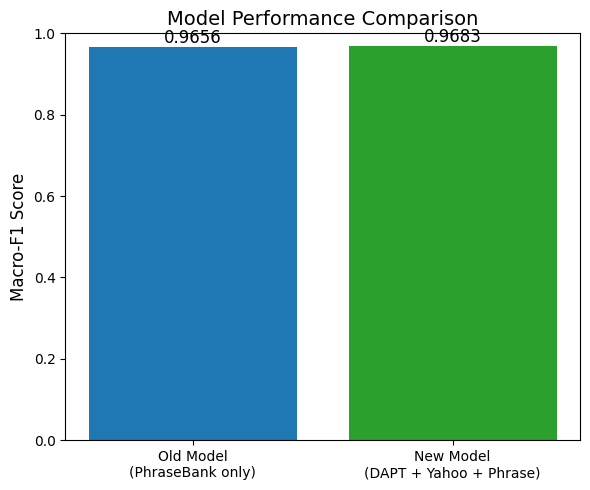

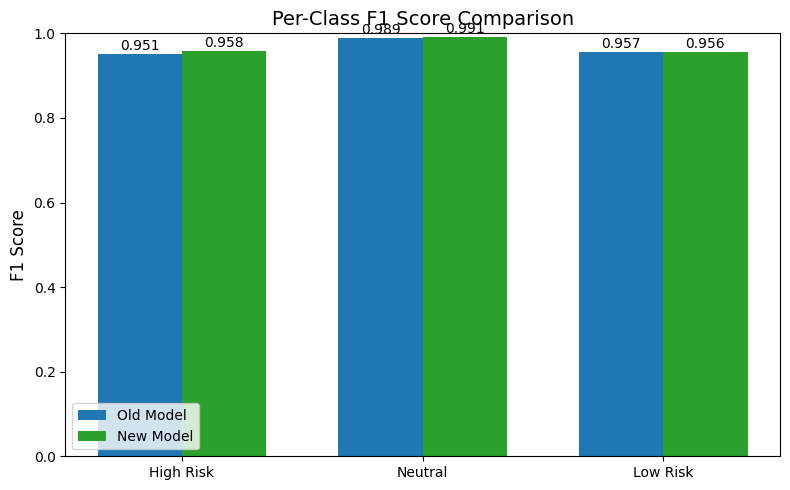

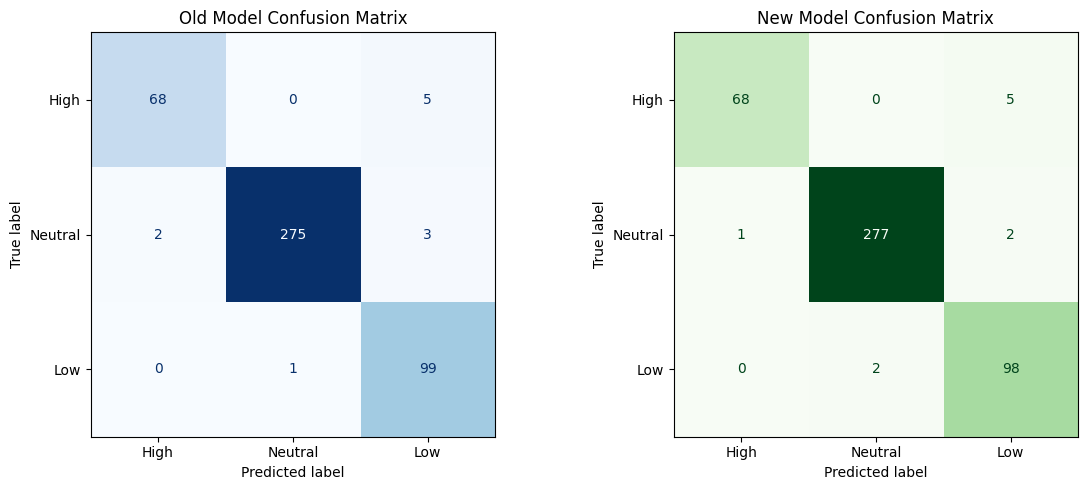


SAMPLE PREDICTION COMPARISON

Text: The company's revenue exceeded expectations, driving stock prices up.
  Old Model -> Low Risk (probs: H=0.003, N=0.001, L=0.996)
  New Model -> Low Risk (probs: H=0.010, N=0.001, L=0.989)

Text: The firm is under investigation for financial fraud and may face severe penalties.
  Old Model -> Neutral (probs: H=0.003, N=0.996, L=0.001)
  New Model -> Neutral (probs: H=0.133, N=0.864, L=0.003)

Text: The market remained flat today with no significant movements.
  Old Model -> Neutral (probs: H=0.012, N=0.984, L=0.004)
  New Model -> Neutral (probs: H=0.001, N=0.999, L=0.000)

✅ Evaluation complete. Figures saved to current directory.


In [ ]:
# ==========================================
# Model Comparison & Training Artifact Logging
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import os

# -------------------- 1. Load Test Data --------------------
print("Loading test data...")
df_test = pd.read_parquet('data/FinancialPhraseBank-v1.0/test-00000-of-00001-14fd3fcb2204380b.parquet')
test_dataset = Dataset.from_pandas(df_test)

# -------------------- 2. Load Old Model (PhraseBank only) --------------------
print("Loading old model (PhraseBank only)...")
old_model_path = "xuyifei1234/finbert-risk-classifier"
old_tokenizer = AutoTokenizer.from_pretrained(old_model_path)
old_model = AutoModelForSequenceClassification.from_pretrained(old_model_path)

# -------------------- 3. Load New Model (DAPT + Yahoo + PhraseBank) --------------------
print("Loading new model (DAPT + Yahoo + PhraseBank)...")
new_model_path = "./best_finbert_risk_model_v2"
new_tokenizer = AutoTokenizer.from_pretrained(new_model_path)
new_model = AutoModelForSequenceClassification.from_pretrained(new_model_path)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
old_model.to(device)
new_model.to(device)

# -------------------- 4. Tokenization Function (Sliding Window) --------------------
def tokenize_with_sliding_window(examples, tokenizer):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=50,
        padding="max_length",
        return_overflowing_tokens=True
    )
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = []
    for i in sample_mapping:
        labels.append(examples["label"][i])
    tokenized_inputs["label"] = labels
    return tokenized_inputs

print("Tokenizing test set...")
# Use old tokenizer (both share same vocab)
tokenized_test = test_dataset.map(
    lambda x: tokenize_with_sliding_window(x, old_tokenizer),
    batched=True,
    remove_columns=test_dataset.column_names
)

# -------------------- 5. Evaluation Function --------------------
def evaluate_model(model, tokenized_dataset, model_name="Model"):
    trainer = Trainer(model=model)
    predictions = trainer.predict(tokenized_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids
    macro_f1 = f1_score(labels, preds, average='macro')
    report = classification_report(labels, preds, target_names=["High Risk", "Neutral", "Low Risk"], output_dict=True)
    return macro_f1, preds, labels, report

print("Evaluating models...")
old_f1, old_preds, labels, old_report = evaluate_model(old_model, tokenized_test, "Old Model")
new_f1, new_preds, _, new_report = evaluate_model(new_model, tokenized_test, "New Model")

# -------------------- 6. Print Comparison Results --------------------
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(f"Old Model (PhraseBank only)      Macro-F1: {old_f1:.4f}")
print(f"New Model (DAPT + Yahoo + Phrase) Macro-F1: {new_f1:.4f}")
if new_f1 > old_f1:
    print(f"✅ Improvement: +{new_f1 - old_f1:.4f}")
else:
    print(f"⚠️  Decline: {new_f1 - old_f1:.4f}")
print("="*60)

# Detailed classification report
print("\n--- Old Model Classification Report ---")
print(classification_report(labels, old_preds, target_names=["High Risk", "Neutral", "Low Risk"]))
print("\n--- New Model Classification Report ---")
print(classification_report(labels, new_preds, target_names=["High Risk", "Neutral", "Low Risk"]))

# -------------------- 7. Visualization --------------------
# Macro-F1 Comparison Bar Chart
plt.figure(figsize=(6, 5))
models = ['Old Model\n(PhraseBank only)', 'New Model\n(DAPT + Yahoo + Phrase)']
f1_scores = [old_f1, new_f1]
bars = plt.bar(models, f1_scores, color=['#1f77b4', '#2ca02c'])
plt.ylabel('Macro-F1 Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.4f}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class F1 Comparison Table
classes = ["High Risk", "Neutral", "Low Risk"]
old_class_f1 = [old_report[c]['f1-score'] for c in classes]
new_class_f1 = [new_report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, old_class_f1, width, label='Old Model', color='#1f77b4')
bars2 = ax.bar(x + width/2, new_class_f1, width, label='New Model', color='#2ca02c')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 1)
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(labels, old_preds, display_labels=["High", "Neutral", "Low"],
                                        ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Old Model Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(labels, new_preds, display_labels=["High", "Neutral", "Low"],
                                        ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('New Model Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------- 8. Sample Predictions --------------------
def predict_sample(model, tokenizer, text, device="cuda"):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
    id2label = {0: "High Risk", 1: "Neutral", 2: "Low Risk"}
    return id2label[pred], probs.cpu().numpy()[0]

samples = [
    "The company's revenue exceeded expectations, driving stock prices up.",
    "The firm is under investigation for financial fraud and may face severe penalties.",
    "The market remained flat today with no significant movements."
]

print("\n" + "="*60)
print("SAMPLE PREDICTION COMPARISON")
print("="*60)
for text in samples:
    old_label, old_probs = predict_sample(old_model, old_tokenizer, text, device)
    new_label, new_probs = predict_sample(new_model, new_tokenizer, text, device)
    print(f"\nText: {text}")
    print(f"  Old Model -> {old_label} (probs: H={old_probs[0]:.3f}, N={old_probs[1]:.3f}, L={old_probs[2]:.3f})")
    print(f"  New Model -> {new_label} (probs: H={new_probs[0]:.3f}, N={new_probs[1]:.3f}, L={new_probs[2]:.3f})")

print("\n✅ Evaluation complete. Figures saved to current directory.")

#CRF-NER

In [ ]:
!pip install sklearn-crfsuite seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=d672264008bbd08528f6e4d0fa05e852a74009545afc25a12937d7c499e69d6f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
# ==========================================
# CoNLL-2003 Data Loading and CRF-based NER
# ==========================================

import json
import os
import re
import sklearn_crfsuite
from seqeval.metrics import classification_report, f1_score
import joblib

# ---------- 4.1 Load CoNLL-2003 JSONL data ----------
def load_jsonl(path):
    with open(path, "r") as f:
        return [json.loads(line) for line in f]

# 修改点：因为之前已经 %cd 到了 data_path，这里直接用相对路径即可，不要再加 data_path
base_path = "data/conll2003"

train_data = load_jsonl(base_path + "/train.json")
valid_data = load_jsonl(base_path + "/valid.json")
test_data  = load_jsonl(base_path + "/test.json")

print("Train size:", len(train_data))
print("Sample instance:", train_data[0])

# ---------- 4.2 Load label mapping ----------
with open(base_path + "/label.json") as f:
    label_map = json.load(f)

# label_map is label -> id, so reverse it
id_to_label = {v: k for k, v in label_map.items()}
print("ID to label:", id_to_label)

def convert_labels(example, id_to_label):
    return [id_to_label[int(i)] for i in example["tags"]]

train_sentences = [x["tokens"] for x in train_data]
train_labels = [convert_labels(x, id_to_label) for x in train_data]

valid_sentences = [x["tokens"] for x in valid_data]
valid_labels = [convert_labels(x, id_to_label) for x in valid_data]

test_sentences = [x["tokens"] for x in test_data]
test_labels = [convert_labels(x, id_to_label) for x in test_data]

print("Sample sentence:", train_sentences[0])
print("Sample labels:", train_labels[0])

# ---------- 4.3 Define CRF features ----------
def word2features(sent, i):
    word = sent[i]

    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }

    if i > 0:
        prev_word = sent[i - 1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
        })
    else:
        features['BOS'] = True

    if i < len(sent) - 1:
        next_word = sent[i + 1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
        })
    else:
        features['EOS'] = True

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

# ---------- 4.4 Prepare CRF inputs ----------
X_train = [sent2features(sent) for sent in train_sentences]
y_train = train_labels

X_valid = [sent2features(sent) for sent in valid_sentences]
y_valid = valid_labels

X_test = [sent2features(sent) for sent in test_sentences]
y_test = test_labels

print("CRF training instances:", len(X_train))
print("Sample token features:", X_train[0][0])

# ---------- 4.5 Train CRF ----------
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)

print("Training CRF...")
crf.fit(X_train, y_train)
print("CRF training complete.")
joblib.dump(crf, "crf_org_extractor.pkl")

# ---------- 4.6 Evaluate CRF ----------
y_pred = crf.predict(X_test)

print("Overall NER results:")
print(classification_report(y_test, y_pred))
print("Overall F1:", f1_score(y_test, y_pred))

def keep_only_org(labels):
    new_labels = []
    for sent in labels:
        new_sent = []
        for tag in sent:
            if tag in ["B-ORG", "I-ORG"]:
                new_sent.append(tag)
            else:
                new_sent.append("O")
        new_labels.append(new_sent)
    return new_labels

y_test_org = keep_only_org(y_test)
y_pred_org = keep_only_org(y_pred)

print("ORG-only results:")
print(classification_report(y_test_org, y_pred_org))
print("ORG-only F1:", f1_score(y_test_org, y_pred_org))


Train size: 14041
Sample instance: {'tags': [1, 0, 2, 0, 0, 0, 2, 0, 0], 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']}
ID to label: {0: 'O', 1: 'B-ORG', 2: 'B-MISC', 3: 'B-PER', 4: 'I-PER', 5: 'B-LOC', 6: 'I-ORG', 7: 'I-MISC', 8: 'I-LOC'}
Sample sentence: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Sample labels: ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']
CRF training instances: 14041
Sample token features: {'bias': 1.0, 'word.lower()': 'eu', 'word[-3:]': 'EU', 'word[-2:]': 'EU', 'word.isupper()': True, 'word.istitle()': False, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': 'rejects', '+1:word.istitle()': False, '+1:word.isupper()': False}
Training CRF...
CRF training complete.
Overall NER results:
              precision    recall  f1-score   support

         LOC       0.85      0.82      0.84      1668
        MISC       0.78      0.74      0.76       702
         ORG       0.78    

In [ ]:
# ==========================================
# Load the Fine-Tuned FinBERT Risk Classifier
# ==========================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

finbert_model_path = "./best_finbert_risk_model_v2"

print("Model path exists:", os.path.exists(finbert_model_path))
print("Model files:", os.listdir(finbert_model_path))

risk_tokenizer = AutoTokenizer.from_pretrained(finbert_model_path, local_files_only=True)
risk_model = AutoModelForSequenceClassification.from_pretrained(finbert_model_path, local_files_only=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
risk_model.to(device)
risk_model.eval()

print("FinBERT loaded successfully on", device)

id2label = {
    0: "High Risk",
    1: "Neutral",
    2: "Low Risk"
}

def predict_risk(text, model, tokenizer, device):
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=512,
        padding="max_length",
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        pred_prob = probs[0, pred_id].item()

    return {
        "label_id": pred_id,
        "label": id2label[pred_id],
        "confidence": pred_prob,
        "probabilities": probs.cpu().numpy()[0]
    }

sample_text = "Apple may face significant regulatory pressure in China next quarter."
risk_result = predict_risk(sample_text, risk_model, risk_tokenizer, device)
print("Sample risk prediction:", risk_result)

Model path exists: True
Model files: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully on cuda
Sample risk prediction: {'label_id': 0, 'label': 'High Risk', 'confidence': 0.9788936972618103, 'probabilities': array([0.9788937 , 0.01886754, 0.00223871], dtype=float32)}


In [ ]:
# ==========================================
# Define Inference Functions
# ==========================================

from sentence_transformers import util

# ---------- 1 SBERT filter ----------
def sbert_keep(title, body, sbert_model, threshold):
    title_emb = sbert_model.encode([title], convert_to_tensor=True)
    body_emb = sbert_model.encode([body], convert_to_tensor=True)

    print("title_emb shape:", title_emb.shape)
    print("body_emb shape:", body_emb.shape)

    score = util.pairwise_cos_sim(title_emb, body_emb).item()
    return score >= threshold, score

# ---------- 2 CRF-based ORG extraction ----------
def simple_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text)

def extract_org_entities(tokens, tags):
    entities = []
    current = []

    for token, tag in zip(tokens, tags):
        if tag == "B-ORG":
            if current:
                entities.append(" ".join(current))
            current = [token]
        elif tag == "I-ORG":
            if current:
                current.append(token)
        else:
            if current:
                entities.append(" ".join(current))
                current = []

    if current:
        entities.append(" ".join(current))

    # deduplicate while preserving order
    deduped = []
    seen = set()
    for ent in entities:
        if ent not in seen:
            deduped.append(ent)
            seen.add(ent)

    return deduped

def run_crf_org_extraction(text, crf):
    tokens = simple_tokenize(text)
    features = sent2features(tokens)
    pred_tags = crf.predict_single(features)
    orgs = extract_org_entities(tokens, pred_tags)

    return {
        "tokens": tokens,
        "tags": pred_tags,
        "orgs": orgs
    }

# ---------- 3 Alert trigger logic ----------
def should_trigger_alert(risk_result, high_risk_threshold=0.30):
    high_risk_prob = float(risk_result["probabilities"][0])

    return (
        risk_result["label"] == "High Risk"
        or high_risk_prob >= high_risk_threshold
    )

def build_alert_message(result):
    if not result["passed_sbert_filter"]:
        return "Filtered out: headline-body mismatch or clickbait-like content."

    if not result["alert_triggered"]:
        return (
            f"No alert triggered. Risk label: {result['risk_label']} "
            f"(confidence={result['risk_confidence']:.3f})."
        )

    org_part = ", ".join(result["orgs"]) if result["orgs"] else "No company identified"

    return (
        f"ALERT: Potential financial risk detected. "
        f"Risk label = {result['risk_label']} "
        f"(confidence={result['risk_confidence']:.3f}, "
        f"high-risk prob={result['high_risk_probability']:.3f}). "
        f"Affected organization(s): {org_part}."
    )

In [ ]:
# ==========================================
# End-to-End News Risk Alert Pipeline
# ==========================================

def full_news_pipeline(
    title,
    body,
    sbert_model,
    threshold,
    risk_model,
    risk_tokenizer,
    crf,
    device,
    high_risk_threshold=0.30
):
    result = {
        "title": title,
        "body": body,
        "passed_sbert_filter": False,
        "similarity_score": None,
        "risk_label": None,
        "risk_confidence": None,
        "high_risk_probability": None,
        "alert_triggered": False,
        "orgs": [],
        "ner_tags": None,
        "alert_message": None
    }

    # Step 1: SBERT filtering
    keep, sim_score = sbert_keep(title, body, sbert_model, threshold)
    result["passed_sbert_filter"] = keep
    result["similarity_score"] = sim_score

    if not keep:
        result["alert_message"] = build_alert_message(result)
        return result

    # Step 2: Risk classification
    text_for_risk = title + " " + body
    risk_result = predict_risk(text_for_risk, risk_model, risk_tokenizer, device)

    result["risk_label"] = risk_result["label"]
    result["risk_confidence"] = risk_result["confidence"]
    result["high_risk_probability"] = float(risk_result["probabilities"][0])

    # Step 3: Alert trigger
    triggered = should_trigger_alert(
        risk_result,
        high_risk_threshold=high_risk_threshold
    )
    result["alert_triggered"] = triggered

    # Step 4: ORG extraction if triggered
    if triggered:
        ner_result = run_crf_org_extraction(text_for_risk, crf)
        result["orgs"] = ner_result["orgs"]
        result["ner_tags"] = list(zip(ner_result["tokens"], ner_result["tags"]))

    # Step 5: Build alert message
    result["alert_message"] = build_alert_message(result)

    return result

In [ ]:
# ==========================================
# Run Example News Through the Pipeline
# ==========================================

title = "Apple faces regulatory pressure in China"
body = "Apple may face significant regulatory challenges in China next quarter as authorities tighten market rules."

result = full_news_pipeline(
    title=title,
    body=body,
    sbert_model=news_filter.model,
    threshold=news_filter.optimal_threshold,
    risk_model=risk_model,
    risk_tokenizer=risk_tokenizer,
    crf=crf,
    device=device,
    high_risk_threshold=0.30
)

print(result["alert_message"])
print(result)